# Statistical significance of Cooja simulation results

This notebook analyzes the statistical variability of metrics collected from repeated Cooja simulations. The input data were exported to `exp-cooja.txt` as a Python/MongoDB-like list of 103 simulation documents. Each document represents one execution of the same SimLab individual/topology under a different Cooja `random_seed`. This export is not the full optimization archive; it is the per-seed Cooja result set for one individual, used here to estimate simulation noise and confidence in the reported metrics.

The methodology is the following. The `mo-engine` reads an experiment document, runs the `batch` strategy and queues one simulation per random seed. The simulation seed is written into the generated Cooja XML as `randomSeed`. The `master-node` then downloads the generated `simulation.csc`, optional `positions.dat`, and the firmware source files from MongoDB/GridFS, sends them to a Cooja container over SSH/SCP, and runs Cooja in no-GUI mode with `cooja.jar`.

Inside the simulation, the Contiki-NG firmware uses an RPL/UDP root and sensor nodes. Sensor nodes periodically report energy, traffic counters, link quality, and latency-related fields. The root mote logs those reports as JSON lines in `COOJA.testlog`. After each run, the `master-node` retrieves the log, converts the JSON records emitted by `[Mote:1]` into a CSV file, and evaluates the experiment `data_conversion_config`: energy metrics are summed, counters such as sent/received packets are computed as last-minus-first per node, and latency/hops metrics are averaged. The resulting aggregate is stored in MongoDB as `network_metrics`.

In this notebook, the exported `ObjectId(...)` values are first converted to strings, the file is parsed as a Python structure, and each `network_metrics` dictionary is expanded into a pandas `DataFrame`. Therefore, each row corresponds to one Cooja random seed for the same individual, and each numeric column corresponds to one observed aggregate metric. The rest of the notebook computes descriptive statistics, confidence intervals, and subsampling experiments to evaluate how many simulation repetitions are needed to estimate the main metrics with stable precision.

In [24]:
import ast
import re
from pathlib import Path

EXP_COOJA_PATH = Path("exp-cooja.txt")

raw_data = EXP_COOJA_PATH.read_text(encoding="utf-8")
raw_data = re.sub(r"ObjectId\('([^']+)'\)", r"'\1'", raw_data)
result = ast.literal_eval(raw_data)

print(result)

[{'_id': '69b0a66518535da9480ae8c6', 'individual_id': 5107467298376595976, 'random_seed': 336157, 'network_metrics': {'latency': 109.66996931170539, 'energy': 2962624.0, 'throughput': 19334.0, 'cpu_energy_mj': 244976.0, 'lpm_energy_mj': 0.0, 'radio_tx_energy_mj': 4132.0, 'radio_rx_energy_mj': 2713516.0, 'total_sent': 11657.0, 'total_received': 9018.0, 'server_sent': 19334.0, 'bytes_tx': 0.0, 'bytes_rx': 132.0, 'server_bytes_rx': 0.0, 'r2n_latency': 473.73958790004383, 'n2r_latency': 1.6766238410177397e+19, 'hops': 1.2716352476983779, 'rtt_latency': 109.66996931170539}}, {'_id': '69b0a66518535da9480ae8ce', 'individual_id': 5107467298376595976, 'random_seed': 667370, 'network_metrics': {'latency': 84.56860364267129, 'energy': 3035826.0, 'throughput': 18692.0, 'cpu_energy_mj': 250905.0, 'lpm_energy_mj': 0.0, 'radio_tx_energy_mj': 2852.0, 'radio_rx_energy_mj': 2782069.0, 'total_sent': 11745.0, 'total_received': 8054.0, 'server_sent': 18692.0, 'bytes_tx': 0.0, 'bytes_rx': 108.0, 'server_byt

In [25]:
from typing import Any
import pandas as pd

def json_to_dataframe(data: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []

    for doc in data:
        metrics = doc.get("network_metrics", {})        
        row = {
            "id": str(doc.get("random_seed"))
        }
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)

df = json_to_dataframe(result)

print(df)

         id     latency     energy  throughput  cpu_energy_mj  lpm_energy_mj  \
0    336157  109.669969  2962624.0     19334.0       244976.0            0.0   
1    667370   84.568604  3035826.0     18692.0       250905.0            0.0   
2     35239  109.243967  3152425.0     19142.0       261072.0            0.0   
3      5881  106.857256  3003842.0     19292.0       248384.0            0.0   
4    656466   72.832207  3001059.0     18642.0       249355.0            0.0   
..      ...         ...        ...         ...            ...            ...   
98    48353  106.287479  3023177.0     19490.0       250473.0            0.0   
99   219533  108.767050  2962781.0     19292.0       244859.0            0.0   
100  123456  116.611572  2964168.0     18619.0       243531.0            0.0   
101  234567   81.209223  3105767.0     18683.0       256580.0            0.0   
102  345678   71.868130  3091493.0     18391.0       255677.0            0.0   

     radio_tx_energy_mj  radio_rx_energ

                metric          mean           var           std  \
0              latency  9.536618e+01  2.539245e+02  1.593501e+01   
1               energy  3.003358e+06  3.419394e+09  5.847559e+04   
2           throughput  1.886596e+04  1.510852e+05  3.886968e+02   
3        cpu_energy_mj  2.476999e+05  2.447324e+07  4.947044e+03   
4        lpm_energy_mj  0.000000e+00  0.000000e+00  0.000000e+00   
5   radio_tx_energy_mj  3.412641e+03  6.172613e+05  7.856598e+02   
6   radio_rx_energy_mj  2.752245e+06  2.882618e+09  5.369002e+04   
7           total_sent  1.157581e+04  1.036326e+04  1.018001e+02   
8       total_received  8.445757e+03  4.198113e+05  6.479285e+02   
9          server_sent  1.886596e+04  1.510852e+05  3.886968e+02   
10            bytes_tx  0.000000e+00  0.000000e+00  0.000000e+00   
11            bytes_rx  1.279223e+02  2.048567e+02  1.431281e+01   
12     server_bytes_rx  0.000000e+00  0.000000e+00  0.000000e+00   
13         r2n_latency  4.677686e+18  1.306036e+

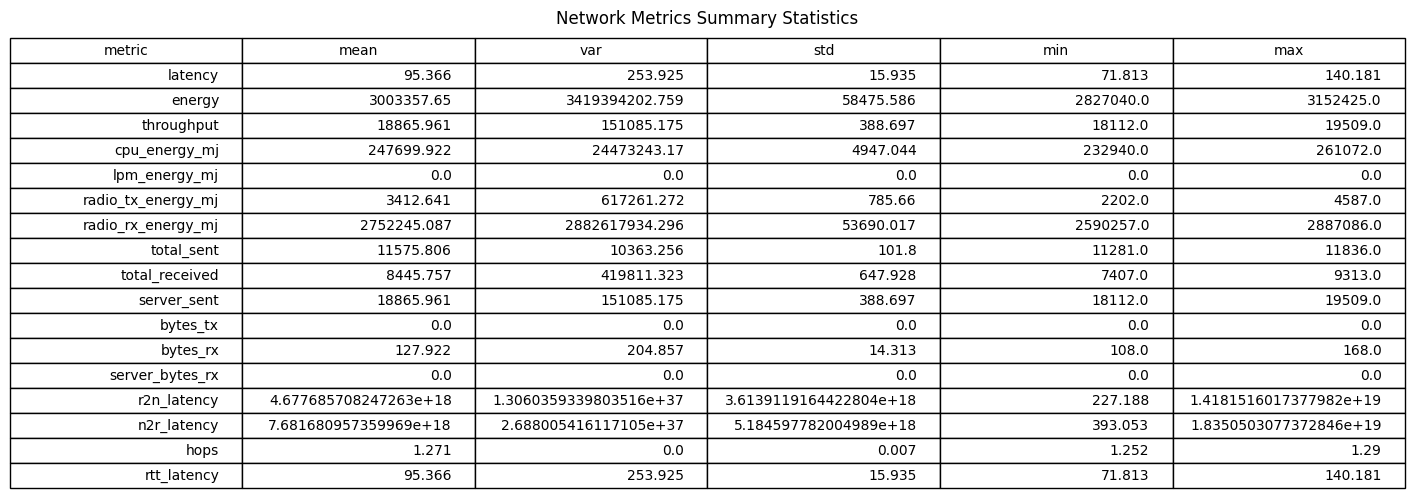

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

columns = df.columns.tolist()
columns.remove("id")

# ------------------------------------------------------------
# Build statistics table
# ------------------------------------------------------------
stats = []

for column in columns:
    stats.append({
        "metric": column,
        "mean": df[column].mean(),
        "var": df[column].var(),
        "std": df[column].std(),
        "min": df[column].min(),
        "max": df[column].max(),
    })

stats_df = pd.DataFrame(stats)

print(stats_df)

# ------------------------------------------------------------
# Plot table
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

table = ax.table(
    cellText=stats_df.round(3).values,
    colLabels=stats_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.8, 1.5)

plt.title("Network Metrics Summary Statistics")
plt.show()

103
       metric          mean           var           std        cv  \
0     latency  9.536618e+01  2.539245e+02     15.935010  0.167093   
1      energy  3.003358e+06  3.419394e+09  58475.586382  0.019470   
2  throughput  1.886596e+04  1.510852e+05    388.696765  0.020603   

            se        ci_low       ci_high  
0     1.570123  9.228873e+01  9.844362e+01  
1  5761.770732  2.992065e+06  3.014651e+06  
2    38.299430  1.879089e+04  1.894103e+04  
       metric       mean        var        std         cv         se  \
0     latency  9.537e+01  2.539e+02  1.594e+01  1.671e-01  1.570e+00   
1      energy  3.003e+06  3.419e+09  5.848e+04  1.947e-02  5.762e+03   
2  throughput  1.887e+04  1.511e+05  3.887e+02  2.060e-02  3.830e+01   

      ci_low    ci_high  
0  9.229e+01  9.844e+01  
1  2.992e+06  3.015e+06  
2  1.879e+04  1.894e+04  


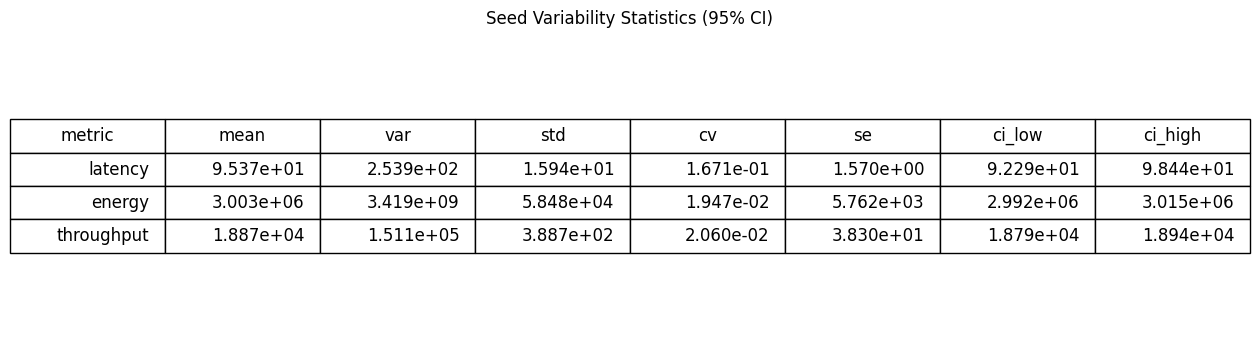

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Metrics of interest
# ------------------------------------------------------------
metrics = ["latency", "energy", "throughput"]

n = len(df)
print(n)
# ------------------------------------------------------------
# Build statistics table
# ------------------------------------------------------------
stats = []

for column in metrics:

    mean = df[column].mean()
    var = df[column].var()
    std = df[column].std()

    cv = std / mean if mean != 0 else np.nan
    se = std / np.sqrt(n)

    ci_low = mean - 1.96 * se
    ci_high = mean + 1.96 * se

    stats.append({
        "metric": column,
        "mean": mean,
        "var": var,
        "std": std,
        "cv": cv,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

stats_df = pd.DataFrame(stats)

print(stats_df)

# ------------------------------------------------------------
# Convert numeric columns to scientific notation
# ------------------------------------------------------------
def sci(x):
    if isinstance(x, (int, float, np.floating)):
        return f"{x:.3e}"
    return x

display_df = stats_df.copy()

for col in display_df.columns[1:]:
    display_df[col] = display_df[col].apply(sci)

print(display_df)

# ------------------------------------------------------------
# Plot table
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2.0, 2.0)

plt.title("Seed Variability Statistics (95% CI)")
plt.show()

In [28]:
import numpy as np

# ------------------------------------------------------------
# James-Stein estimator
# ------------------------------------------------------------
def james_stein_to_mean(means: np.ndarray, variances: np.ndarray) -> np.ndarray:
    k = means.size
    if k < 3:
        return means

    mu_bar: np.ndarray = means.mean()
    sigma2: float = np.mean(variances)

    diff2: float = np.sum((means - mu_bar) ** 2)

    if diff2 <= 0 or sigma2 <= 0:
        return means
    
    shrink: float = max(0, 1 - ((k - 2) * sigma2) / diff2)
    
    print(f"Shrinkage factor: {shrink:.4f}")
    print(f"Original means: {means}")
    print(f"Global mean (mu_bar): {mu_bar:.4f}")
    print(f"Variances: {variances}")

    return mu_bar + shrink * (means - mu_bar)


def james_stein_heteroscedastic(means: np.ndarray, variances: np.ndarray) -> np.ndarray:
    k = means.size
    if k < 3:
        return means

    mu_bar: float = means.mean()

    diff2: float = np.sum((means - mu_bar) ** 2)

    if diff2 <= 0:
        return means

    shrink: np.ndarray = 1 - ((k - 2) * variances) / diff2
    shrink = np.clip(shrink, 0.0, 1.0)

    print(f"Shrinkage factors: {shrink}")
    print(f"Original means: {means}")
    print(f"Global mean (mu_bar): {mu_bar:.4f}")
    print(f"Variances: {variances}")

    return mu_bar + shrink * (means - mu_bar)


def james_stein_to_opt(means: np.ndarray, variances: np.ndarray, mu_bar: np.ndarray) -> np.ndarray:
    k = means.size
    if k < 3:
        return means

    sigma2: float = np.mean(variances)

    diff2: float = np.sum((means - means.mean()) ** 2)

    if diff2 <= 0 or sigma2 <= 0:
        return means
    
    shrink: float = max(0, 1 - ((k - 2) * sigma2) / diff2)
    
    print(f"Shrinkage factor: {shrink:.4f}")
    print(f"Original means: {means}")
    print(f"Variances: {variances}")

    return mu_bar + shrink * (means - mu_bar)


def james_stein(means: np.ndarray, variances: np.ndarray) -> np.ndarray:
    k = means.size
    if k < 3:
        return means

    return [(1-variances[i]*(k-2)/means.mean()**2)*means[i] for i in range(len(means))]


# ------------------------------------------------------------
# Build statistics table
# ------------------------------------------------------------
columns = df.columns.tolist()
columns.remove("id")

means = []
variances = []
stats = []
directions: np.ndarray = []

for column in ["latency", "throughput", "energy"]:
    m = df[column].mean()
    v = df[column].var()

    means.append(m)
    variances.append(v)
    if column == "latency" or column == "energy":
        directions.append(df[column].max())
    else:
        directions.append(df[column].min())

means = np.array(means)
variances = np.array(variances)

print(f"Original means:\n\t{means[0]:.4f}, {means[1]:.4f}, {means[2]:.4f}")
print("---")

js_values = james_stein(means, variances)
print(f'James-Stein estimates:\n\t{js_values[0]:.4f}, {js_values[1]:.4f}, {js_values[2]:.4f}')
print("---")

js_values_to_mean = james_stein_to_mean(means, variances)
print(f'James-Stein estimates (to mean):\n\t{js_values_to_mean[0]:.4f}, {js_values_to_mean[1]:.4f}, {js_values_to_mean[2]:.4f}')
print("---")

js_values_heteroscedastic = james_stein_heteroscedastic(means, variances)
print(f'James-Stein estimates (heteroscedastic):\n\t{js_values_heteroscedastic[0]:.4f}, {js_values_heteroscedastic[1]:.4f}, {js_values_heteroscedastic[2]:.4f}')
print("---")

js_values_to_opt = james_stein_to_opt(means, variances, directions)
print(f'James-Stein estimates (to opt):\n\t{js_values_to_opt[0]:.4f}, {js_values_to_opt[1]:.4f}, {js_values_to_opt[2]:.4f}')

Original means:
	95.3662, 18865.9612, 3003357.6505
---
James-Stein estimates:
	95.3662, 18865.9584, 2993239.1039
---
Shrinkage factor: 0.9998
Original means: [9.53661751e+01 1.88659612e+04 3.00335765e+06]
Global mean (mu_bar): 1007439.6593
Variances: [2.53924532e+02 1.51085175e+05 3.41939420e+09]
James-Stein estimates (to mean):
	287.5141, 19054.5286, 3002976.9351
---
Shrinkage factors: [1.         0.99999997 0.99942778]
Original means: [9.53661751e+01 1.88659612e+04 3.00335765e+06]
Global mean (mu_bar): 1007439.6593
Variances: [2.53924532e+02 1.51085175e+05 3.41939420e+09]
James-Stein estimates (heteroscedastic):
	95.3662, 18865.9862, 3002215.5550
---
Shrinkage factor: 0.9998
Original means: [9.53661751e+01 1.88659612e+04 3.00335765e+06]
Variances: [2.53924532e+02 1.51085175e+05 3.41939420e+09]
James-Stein estimates (to opt):
	95.3747, 18865.8173, 3003386.0846



$$
\epsilon_{js}=v+\Big(1-\frac{d-1}{||\bar{\mu}-v||^2}\Big)\sigma^2I(\bar{\mu}-v)
$$

where:
- $\sigma^2I$ is the covariance matrix.
- $\bar{\mu}=\frac{1}{N}\sum_{i=1}^N x_i$, with $x_i\in\mathbb{R}^d$.
- $v\in\mathbb{R}^d$.

Reference: full-data mean
latency       9.536618e+01
throughput    1.886596e+04
energy        3.003358e+06
dtype: float64

Normalized RMSE: lower is better
    sample_size  mean_error  js_error  mean_error_p95  js_error_p95  shrink  \
0             3      0.5235    0.3197          0.9254        0.8654  0.4622   
1             8      0.3027    0.1727          0.5557        0.4985  0.4227   
2            13      0.2349    0.1316          0.4217        0.3668  0.4204   
3            19      0.1844    0.0969          0.3409        0.2913  0.3825   
4            24      0.1600    0.0822          0.3000        0.2536  0.3749   
5            29      0.1409    0.0703          0.2642        0.2227  0.3565   
6            34      0.1281    0.0612          0.2411        0.2004  0.3374   
7            39      0.1114    0.0490          0.2066        0.1662  0.3052   
8            45      0.1031    0.0439          0.1884        0.1504  0.2955   
9            50      0.0912    0.0347          0.1732 

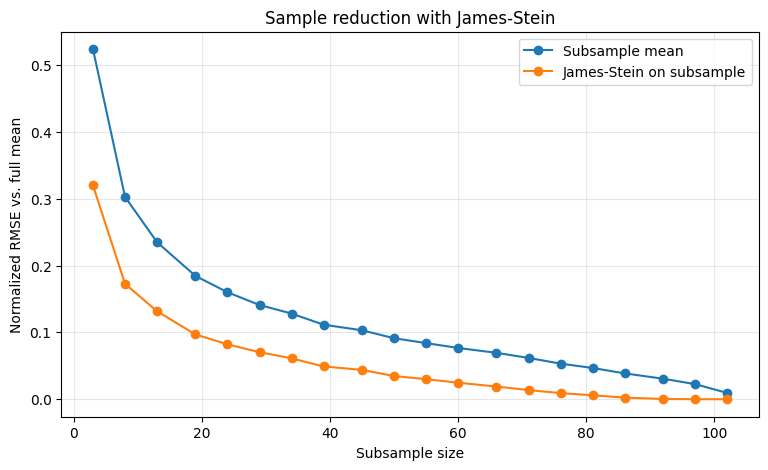

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Subsampling with James-Stein shrinkage
# ------------------------------------------------------------
rng = np.random.default_rng(42)
metrics = ["latency", "throughput", "energy"]
values = df[metrics].astype(float)

n_total = len(values)
n_repetitions = 1000
sample_sizes = np.unique(np.rint(np.linspace(3, n_total - 1, 20)).astype(int))

reference_mean = values.mean().to_numpy()
metric_scale = values.std(ddof=1).replace(0, 1).to_numpy()
# We use the complete mean as the shrinkage target to quantify the possible reduction.
# For a real experiment, replace it with a historical or independent pilot mean.
scaled_values = (values.to_numpy() - reference_mean) / metric_scale


def positive_part_james_stein(means: np.ndarray, variances: np.ndarray) -> tuple[np.ndarray, float]:
    k = means.size
    if k < 3:
        return means, 1.0

    target = np.zeros(k)
    sigma2 = np.nanmean(variances)
    diff2 = np.sum((means - target) ** 2)

    if diff2 <= 0 or sigma2 <= 0 or not np.isfinite(sigma2):
        return means, 1.0

    shrink = max(0.0, 1.0 - ((k - 2) * sigma2) / diff2)
    return target + shrink * (means - target), shrink


records = []

for sample_size in sample_sizes:
    for _ in range(n_repetitions):
        sample_index = rng.choice(n_total, size=sample_size, replace=False)
        sample = scaled_values[sample_index]

        sample_mean_scaled = sample.mean(axis=0)
        sample_var_of_mean = sample.var(axis=0, ddof=1) / sample_size
        js_mean_scaled, shrink = positive_part_james_stein(sample_mean_scaled, sample_var_of_mean)

        sample_mean = reference_mean + sample_mean_scaled * metric_scale
        js_mean = reference_mean + js_mean_scaled * metric_scale

        records.append({
            "sample_size": sample_size,
            "mean_error": np.sqrt(np.mean(((sample_mean - reference_mean) / metric_scale) ** 2)),
            "js_error": np.sqrt(np.mean(((js_mean - reference_mean) / metric_scale) ** 2)),
            "shrink": shrink,
        })

subsample_results = pd.DataFrame(records)
subsample_summary = (
    subsample_results
    .groupby("sample_size", as_index=False)
    .agg(
        mean_error=("mean_error", "mean"),
        js_error=("js_error", "mean"),
        mean_error_p95=("mean_error", lambda values: np.quantile(values, 0.95)),
        js_error_p95=("js_error", lambda values: np.quantile(values, 0.95)),
        shrink=("shrink", "mean"),
    )
)

subsample_summary["js_gain_pct"] = 100 * (1 - subsample_summary["js_error"] / subsample_summary["mean_error"])

equivalent_mean_samples = []
for js_error in subsample_summary["js_error"]:
    candidates = subsample_summary.loc[subsample_summary["mean_error"] <= js_error, "sample_size"]
    equivalent_mean_samples.append(candidates.min() if not candidates.empty else np.nan)

subsample_summary["equivalent_mean_samples"] = equivalent_mean_samples
subsample_summary["saved_samples_vs_mean"] = subsample_summary["equivalent_mean_samples"] - subsample_summary["sample_size"]

print("Reference: full-data mean")
print(pd.Series(reference_mean, index=metrics))
print("\nNormalized RMSE: lower is better")
print(subsample_summary.round(4))

valid_reductions = subsample_summary.loc[subsample_summary["saved_samples_vs_mean"] > 0]
if valid_reductions.empty:
    print("\nIn this simulation, James-Stein did not reduce the number of samples relative to the simple mean.")
else:
    best_row = valid_reductions.loc[valid_reductions["saved_samples_vs_mean"].idxmax()]
    print(
        f"\nLargest estimated reduction: JS with {int(best_row['sample_size'])} samples "
        f"reaches an error similar to the mean using {int(best_row['equivalent_mean_samples'])} samples "
        f"({int(best_row['saved_samples_vs_mean'])} fewer samples)."
    )

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(subsample_summary["sample_size"], subsample_summary["mean_error"], marker="o", label="Subsample mean")
ax.plot(subsample_summary["sample_size"], subsample_summary["js_error"], marker="o", label="James-Stein on subsample")
ax.set_xlabel("Subsample size")
ax.set_ylabel("Normalized RMSE vs. full mean")
ax.set_title("Sample reduction with James-Stein")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Subsampling experiment with the James-Stein estimator

Let $x_i \in \mathbb{R}^d$, $i=1,\ldots,n$, denote the observed metric vectors. In the previous cell we used $d=3$, with coordinates corresponding to `latency`, `throughput`, and `energy`. The full-data mean used as the reference was

$$
\theta = \frac{1}{n}\sum_{i=1}^{n} x_i.
$$

To compare metrics on the same scale, each coordinate was centered relative to this reference and normalized by the sample standard deviation of that metric:

$$
s_j = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_{ij}-\theta_j)^2}, \qquad z_{ij}=\frac{x_{ij}-\theta_j}{s_j}.
$$

With this transformation, estimating the full mean $\theta$ is equivalent to estimating the zero vector in the standardized space. For each subsample size $m$ and repetition $r$, a set $S_{m,r} \subset \{1,\ldots,n\}$ with $|S_{m,r}|=m$ was sampled without replacement. The subsample mean in the standardized space was

$$
\bar z_{m,r}=\frac{1}{m}\sum_{i\in S_{m,r}} z_i.
$$

The variance of each coordinate of the sample mean was estimated by

$$
\hat\sigma^2_{m,r,j}=\frac{1}{m}\cdot\frac{1}{m-1}\sum_{i\in S_{m,r}}(z_{ij}-\bar z_{m,r,j})^2,
$$

and the cell uses the scalar approximation

$$
\hat\tau^2_{m,r}=\frac{1}{d}\sum_{j=1}^{d}\hat\sigma^2_{m,r,j}.
$$

The positive-part James-Stein estimator, with target at the zero vector, was applied as

$$
a_{m,r}=\left(1-\frac{(d-2)\hat\tau^2_{m,r}}{\|\bar z_{m,r}\|_2^2}\right)_+, \qquad \hat z^{JS}_{m,r}=a_{m,r}\bar z_{m,r},
$$

where $(u)_+=\max(u,0)$. The estimators were then transformed back to the original scale:

$$
\hat x^{mean}_{m,r}=\theta+s\odot\bar z_{m,r}, \qquad \hat x^{JS}_{m,r}=\theta+s\odot\hat z^{JS}_{m,r},
$$

where $\odot$ denotes coordinate-wise multiplication. The reported error is the normalized RMSE against the full-data mean:

$$
e(\hat x)=\sqrt{\frac{1}{d}\sum_{j=1}^{d}\left(\frac{\hat x_j-\theta_j}{s_j}\right)^2}.
$$

For each $m$, the experiment repeats this procedure $R=1000$ times and computes the mean and the 95th percentile of the errors for $\hat x^{mean}_{m,r}$ and $\hat x^{JS}_{m,r}$. The percentage gain shown in the table is

$$
100\left(1-\frac{\mathbb{E}_r[e(\hat x^{JS}_{m,r})]}{\mathbb{E}_r[e(\hat x^{mean}_{m,r})]}\right).
$$

The sample reduction is estimated by finding, for each $m$, the smallest size $q$ in the tested grid such that

$$
\mathbb{E}_r[e(\hat x^{mean}_{q,r})] \le \mathbb{E}_r[e(\hat x^{JS}_{m,r})].
$$

When $q>m$, James-Stein with $m$ samples is interpreted as reaching an error comparable to the simple mean with $q$ samples, saving $q-m$ samples in this experimental grid. Because $\theta$ was computed from the full dataset and also used as the shrinkage target, this experiment should be read as a retrospective analysis of possible sample reduction. In a prospective design, the target should be a historical mean or an estimate obtained from an independent pilot sample, to avoid leaking information from the full sample into the estimator.

Evaluation reference: full-data mean
latency       9.536618e+01
throughput    1.886596e+04
energy        3.003358e+06
dtype: float64

Normalized RMSE: lower is better
    sample_size  mean_error  js_error  mean_error_p95  js_error_p95  shrink  \
0             3      0.5235    0.5235          0.9254        0.9267  0.9997   
1             8      0.3027    0.3027          0.5557        0.5566  0.9999   
2            13      0.2349    0.2349          0.4217        0.4220  0.9999   
3            19      0.1844    0.1844          0.3409        0.3415  1.0000   
4            24      0.1600    0.1600          0.3000        0.3002  1.0000   
5            29      0.1409    0.1409          0.2642        0.2643  1.0000   
6            34      0.1281    0.1281          0.2411        0.2411  1.0000   
7            39      0.1114    0.1115          0.2066        0.2065  1.0000   
8            45      0.1031    0.1031          0.1884        0.1883  1.0000   
9            50      0.0912    0.0912      

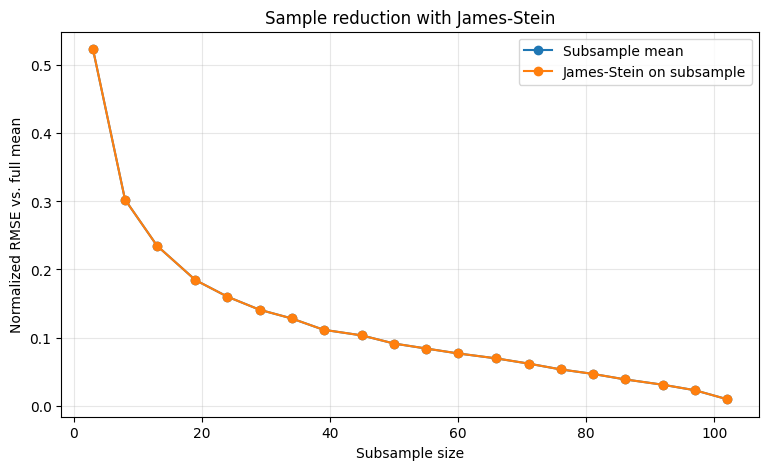

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Subsampling with James-Stein shrinkage
# ------------------------------------------------------------
rng = np.random.default_rng(42)
metrics = ["latency", "throughput", "energy"]
values = df[metrics].astype(float)

n_total = len(values)
n_repetitions = 1000
sample_sizes = np.unique(np.rint(np.linspace(3, n_total - 1, 20)).astype(int))

evaluation_mean = values.mean().to_numpy()
metric_scale = values.std(ddof=1).replace(0, 1).to_numpy()
# The complete mean is used only to evaluate the error.
# The James-Stein shrinkage target is estimated from each subsample.
scaled_values = values.to_numpy() / metric_scale


def positive_part_james_stein(means: np.ndarray, variances: np.ndarray) -> tuple[np.ndarray, float]:
    k = means.size
    if k < 3:
        return means, 1.0

    target = np.repeat(means.mean(), k)
    sigma2 = np.nanmean(variances)
    diff2 = np.sum((means - target) ** 2)

    if diff2 <= 0 or sigma2 <= 0 or not np.isfinite(sigma2):
        return means, 1.0

    shrink = max(0.0, 1.0 - ((k - 2) * sigma2) / diff2)
    return target + shrink * (means - target), shrink


records = []

for sample_size in sample_sizes:
    for _ in range(n_repetitions):
        sample_index = rng.choice(n_total, size=sample_size, replace=False)
        sample = scaled_values[sample_index]

        sample_mean_scaled = sample.mean(axis=0)
        sample_var_of_mean = sample.var(axis=0, ddof=1) / sample_size
        js_mean_scaled, shrink = positive_part_james_stein(sample_mean_scaled, sample_var_of_mean)

        sample_mean = sample_mean_scaled * metric_scale
        js_mean = js_mean_scaled * metric_scale

        records.append({
            "sample_size": sample_size,
            "mean_error": np.sqrt(np.mean(((sample_mean - evaluation_mean) / metric_scale) ** 2)),
            "js_error": np.sqrt(np.mean(((js_mean - evaluation_mean) / metric_scale) ** 2)),
            "shrink": shrink,
        })

subsample_results = pd.DataFrame(records)
subsample_summary = (
    subsample_results
    .groupby("sample_size", as_index=False)
    .agg(
        mean_error=("mean_error", "mean"),
        js_error=("js_error", "mean"),
        mean_error_p95=("mean_error", lambda values: np.quantile(values, 0.95)),
        js_error_p95=("js_error", lambda values: np.quantile(values, 0.95)),
        shrink=("shrink", "mean"),
    )
)

subsample_summary["js_gain_pct"] = 100 * (1 - subsample_summary["js_error"] / subsample_summary["mean_error"])

equivalent_mean_samples = []
for js_error in subsample_summary["js_error"]:
    candidates = subsample_summary.loc[subsample_summary["mean_error"] <= js_error, "sample_size"]
    equivalent_mean_samples.append(candidates.min() if not candidates.empty else np.nan)

subsample_summary["equivalent_mean_samples"] = equivalent_mean_samples
subsample_summary["saved_samples_vs_mean"] = subsample_summary["equivalent_mean_samples"] - subsample_summary["sample_size"]

print("Evaluation reference: full-data mean")
print(pd.Series(evaluation_mean, index=metrics))
print("\nNormalized RMSE: lower is better")
print(subsample_summary.round(4))

valid_reductions = subsample_summary.loc[subsample_summary["saved_samples_vs_mean"] > 0]
if valid_reductions.empty:
    print("\nIn this simulation, James-Stein did not reduce the number of samples relative to the simple mean.")
else:
    best_row = valid_reductions.loc[valid_reductions["saved_samples_vs_mean"].idxmax()]
    print(
        f"\nLargest estimated reduction: JS with {int(best_row['sample_size'])} samples "
        f"reaches an error similar to the mean using {int(best_row['equivalent_mean_samples'])} samples "
        f"({int(best_row['saved_samples_vs_mean'])} fewer samples)."
    )

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(subsample_summary["sample_size"], subsample_summary["mean_error"], marker="o", label="Subsample mean")
ax.plot(subsample_summary["sample_size"], subsample_summary["js_error"], marker="o", label="James-Stein on subsample")
ax.set_xlabel("Subsample size")
ax.set_ylabel("Normalized RMSE vs. full mean")
ax.set_title("Sample reduction with James-Stein")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

Metrics removed because they are entirely zero: ['bytes_tx', 'lpm_energy_mj', 'server_bytes_rx']


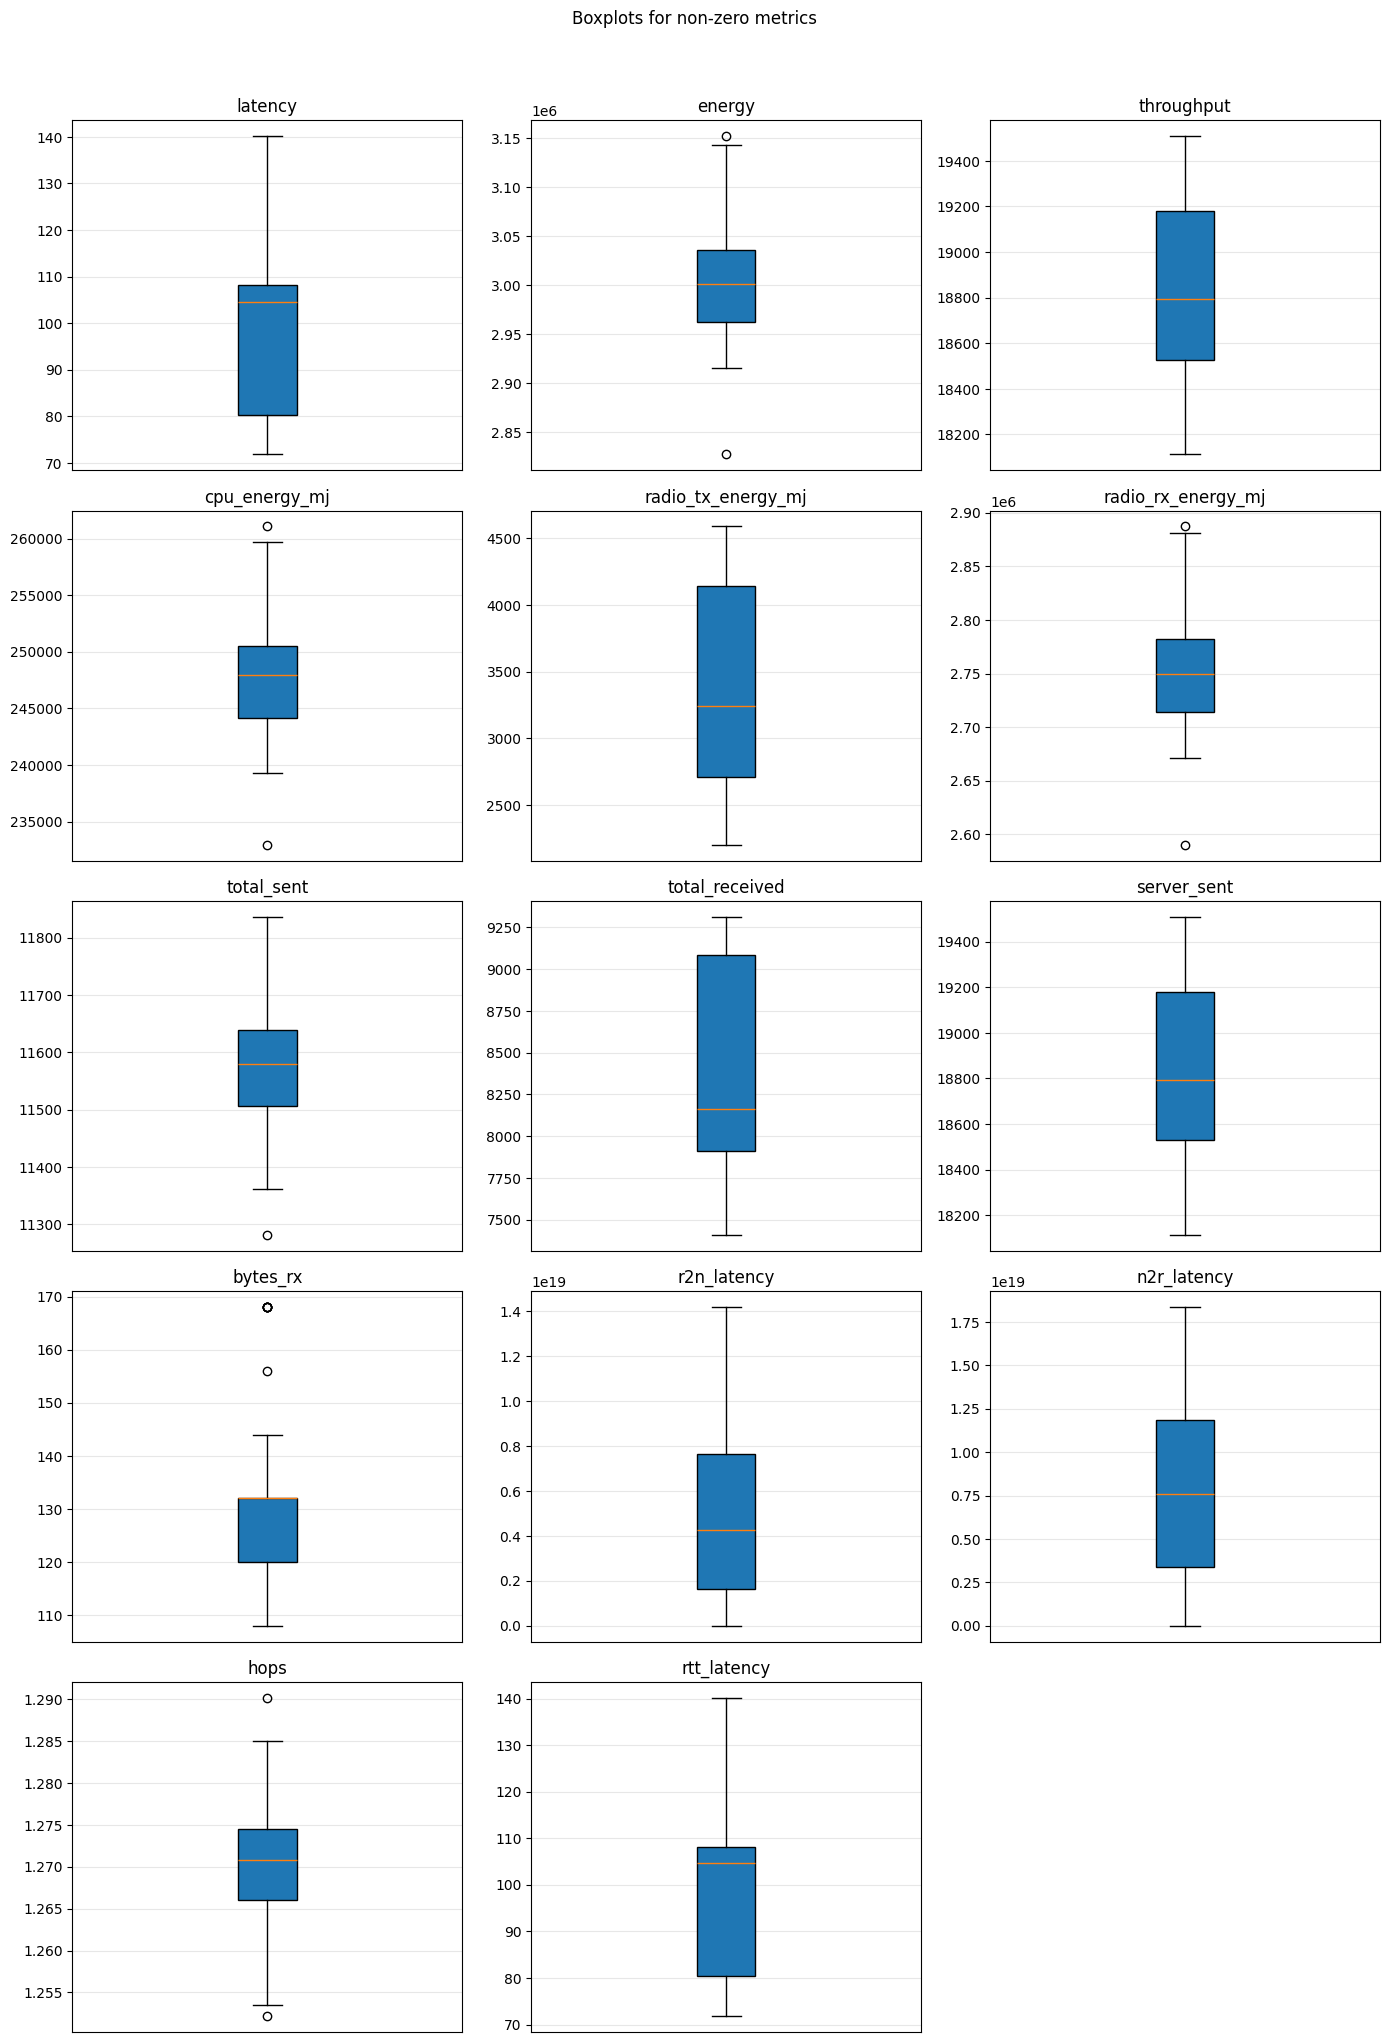

In [41]:
import math
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# Boxplots for non-zero metrics
# ------------------------------------------------------------
numeric_data = df.drop(columns=["id"], errors="ignore").select_dtypes(include="number")
non_zero_columns = numeric_data.columns[(numeric_data != 0).any(axis=0)]
zero_columns = numeric_data.columns.difference(non_zero_columns)
boxplot_data = numeric_data[non_zero_columns]

print(f"Metrics removed because they are entirely zero: {list(zero_columns)}")

n_columns = 3
n_rows = math.ceil(len(boxplot_data.columns) / n_columns)

fig, axes = plt.subplots(n_rows, n_columns, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, boxplot_data.columns):
    ax.boxplot(boxplot_data[column].dropna(), vert=True, patch_artist=True)
    ax.set_title(column)
    ax.set_xticks([])
    ax.grid(True, axis="y", alpha=0.3)

for ax in axes[len(boxplot_data.columns):]:
    ax.axis("off")

fig.suptitle("Boxplots for non-zero metrics", y=1.02)
fig.tight_layout()
plt.show()

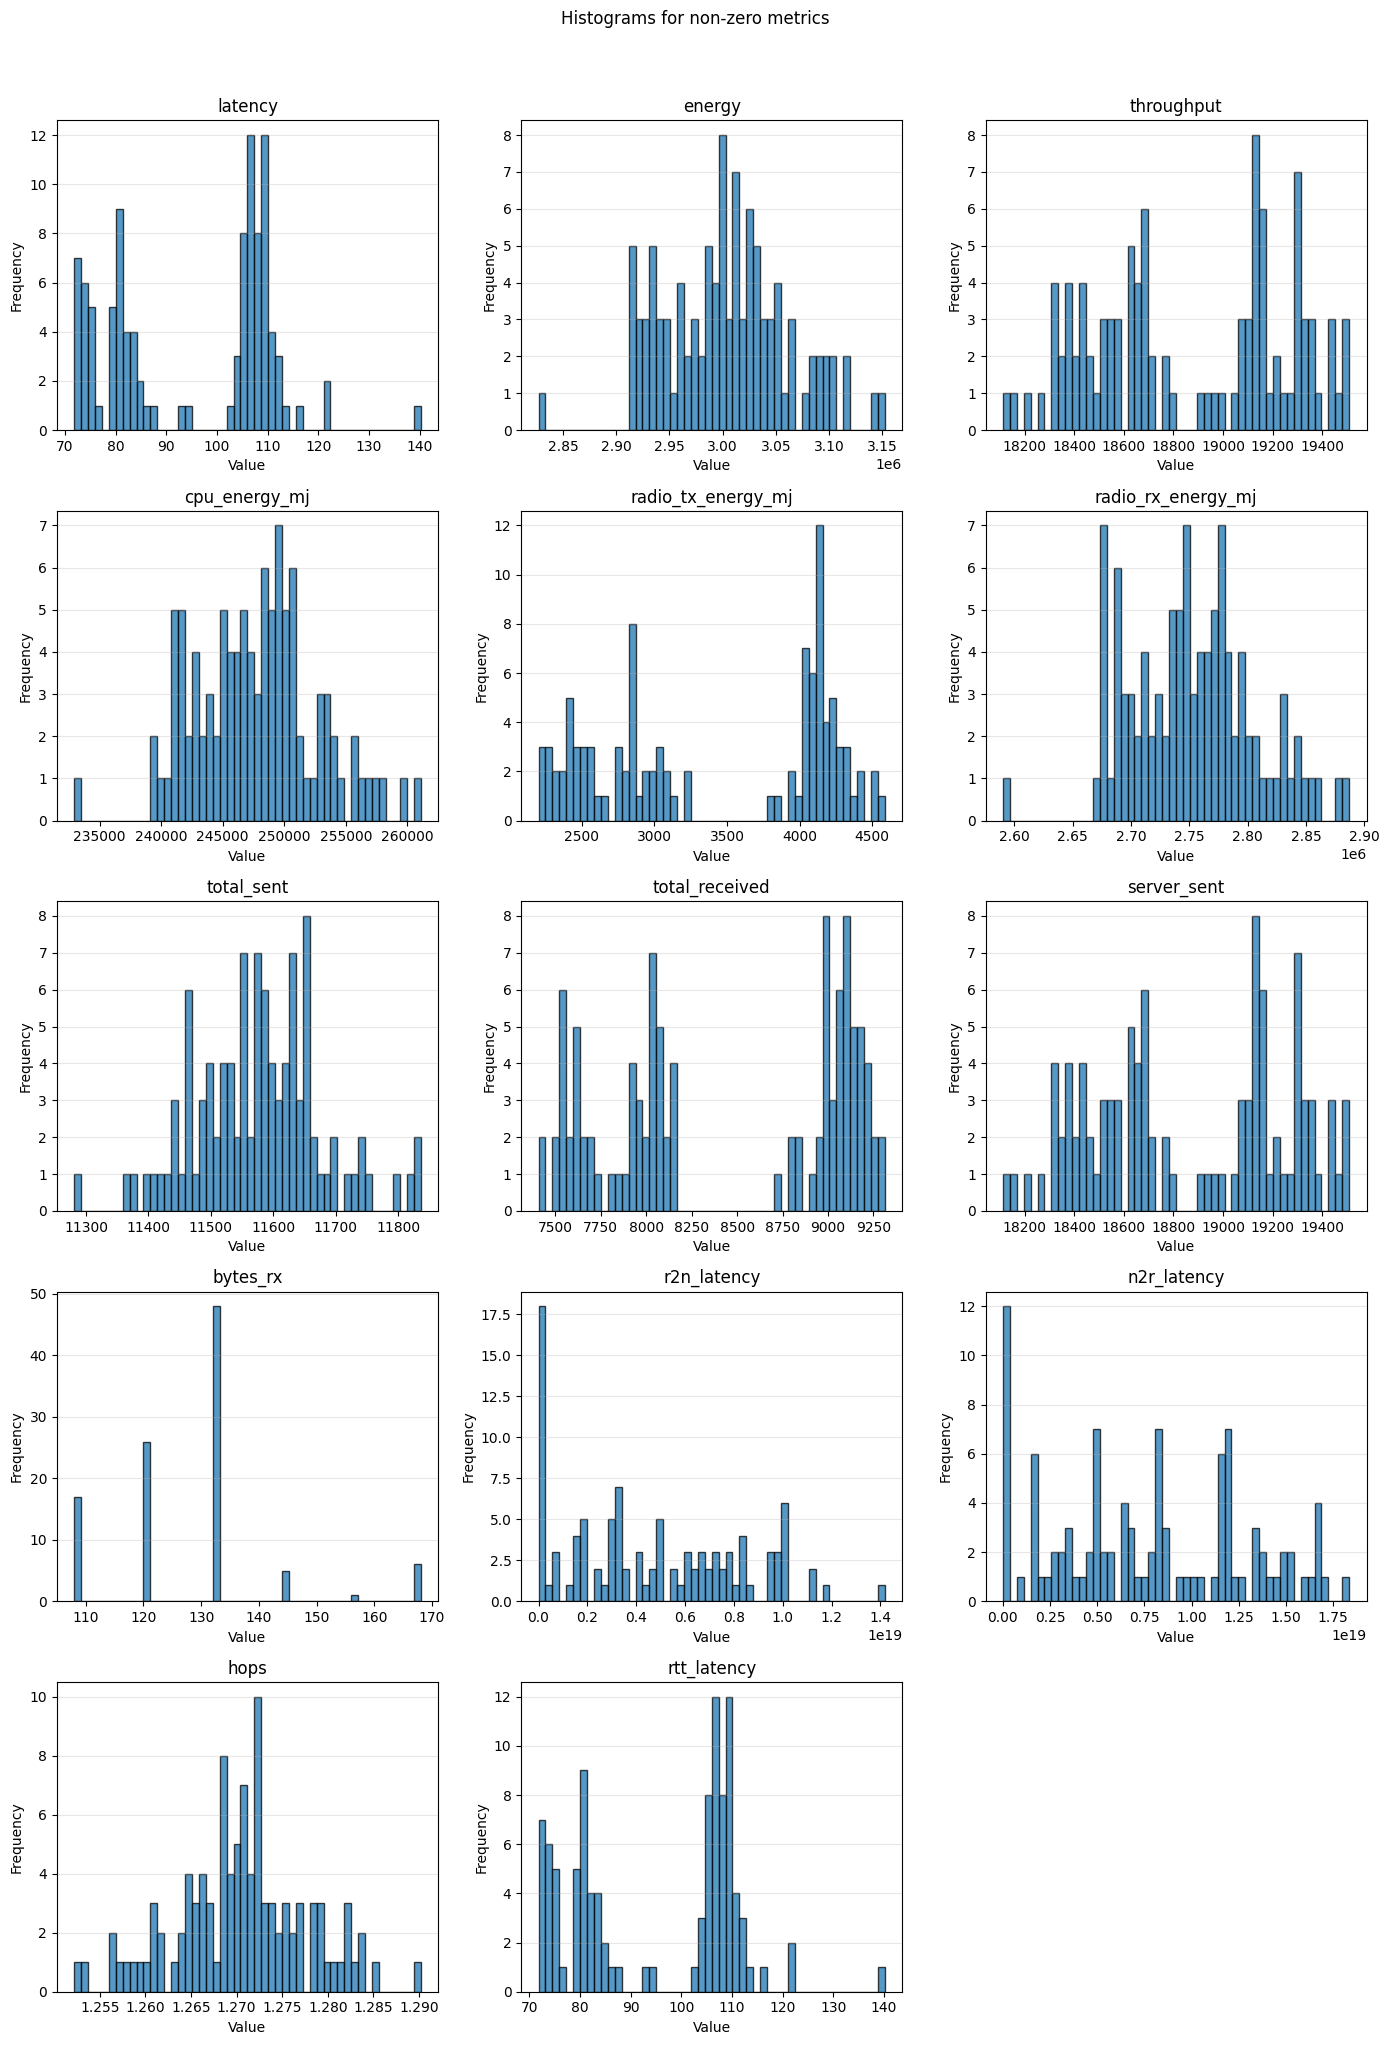

In [43]:
fig, axes = plt.subplots(n_rows, n_columns, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, boxplot_data.columns):
    ax.hist(boxplot_data[column].dropna(), bins=50, edgecolor="black", alpha=0.75)
    ax.set_title(column)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.grid(True, axis="y", alpha=0.3)

for ax in axes[len(boxplot_data.columns):]:
    ax.axis("off")

fig.suptitle("Histograms for non-zero metrics", y=1.02)
fig.tight_layout()
plt.show()

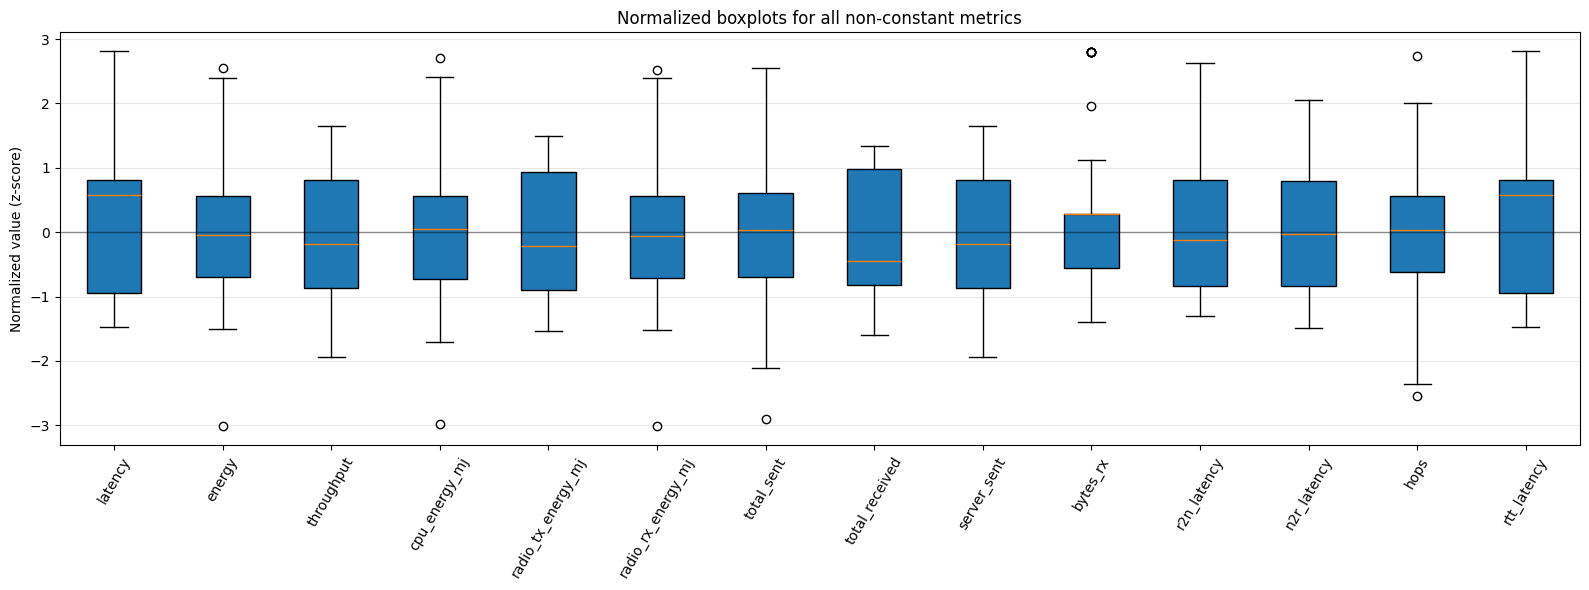

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# Normalized boxplots for all non-constant metrics
# ------------------------------------------------------------
numeric_data = df.drop(columns=["id"], errors="ignore").select_dtypes(include="number")
metric_std = numeric_data.std(ddof=1)
non_constant_columns = metric_std[metric_std > 0].index

normalized_data = (numeric_data[non_constant_columns] - numeric_data[non_constant_columns].mean()) / metric_std[non_constant_columns]

fig, ax = plt.subplots(figsize=(16, 6))
ax.boxplot(
    [normalized_data[column].dropna() for column in normalized_data.columns],
    labels=normalized_data.columns,
    patch_artist=True,
)
ax.axhline(0, color="black", linewidth=1, alpha=0.4)
ax.set_title("Normalized boxplots for all non-constant metrics")
ax.set_ylabel("Normalized value (z-score)")
ax.tick_params(axis="x", rotation=60)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()